[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/navjotts/ML-experiments/blob/master/11%20-%20PCA%20and%20Eigenfaces/PCA_and_Eigenfaces.ipynb)

# Eigenfaces

One of the most interesting ways to understand PCA involves image processing.

Every image can be thought of as a single high dimensional point where each pixel is a dimension of the point.

When presented with a collection of $m$ images in $n$ dimensions, where $n$ is the number of pixels per image, PCA produces a very interesting set of components.


### Image Dataset

[https://www.cl.cam.ac.uk/research/dtg/attarchive/facedatabase.html](https://www.cl.cam.ac.uk/research/dtg/attarchive/facedatabase.html)



In [0]:
!wget http://www.cl.cam.ac.uk/Research/DTG/attarchive/pub/data/att_faces.zip -O att_faces.zip
!unzip att_faces.zip

### Checkout an Image

(112, 92)


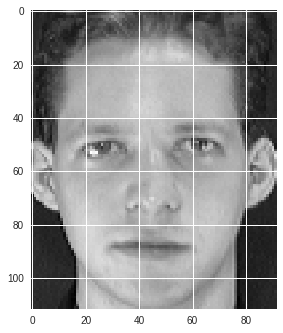

In [3]:
import numpy as np
from scipy.misc import imread
import matplotlib.pyplot as plt

first_img = imread('s1/1.pgm')
first_img = first_img.astype(np.uint8)
first_img = first_img / 255
print(first_img.shape)
plt.imshow(first_img, cmap='gray');

### Prepare data

In [4]:
import glob
imagepaths = glob.glob('**/*.pgm', recursive=True)
print(len(imagepaths))

400


In [7]:
import pandas as pd

images_data = pd.DataFrame([])

for i, path in enumerate(imagepaths):
  if (i+1)%50 == 0: print("===== loading image", i+1)
  img = imread(path)
  img = img.astype(np.uint8)
  img = img / 255
  img = img.flatten()
  data_entry = pd.DataFrame([img])
  images_data = images_data.append(data_entry)

print("\nFinal data:", images_data.shape)

===== loading image 50
===== loading image 100
===== loading image 150
===== loading image 200
===== loading image 250
===== loading image 300
===== loading image 350
===== loading image 400

Final data: (400, 10304)


In [8]:
faces = images_data.copy()
faces.shape

(400, 10304)

### Plotting data

In [0]:
def plot_faces(data):
  per_row = 10
  num_rows = data.shape[0]//per_row
  fig, axes = plt.subplots(num_rows, per_row, figsize=(9, num_rows+1),
                           subplot_kw={'xticks':[], 'yticks':[]},
                           gridspec_kw=dict(hspace=0.01, wspace=0.01))

  for i, ax in enumerate(axes.flat):
      ax.imshow(data.iloc[i].values.reshape(112, 92), cmap="gray")  

In [0]:
def plot_eigenfaces(data, num_rows=None):
  per_row = 10
  num_rows = num_rows if num_rows else data.shape[0]//per_row
  fig, axes = plt.subplots(num_rows, per_row, figsize=(9, num_rows+1),
                           subplot_kw={'xticks':[], 'yticks':[]},
                           gridspec_kw=dict(hspace=0.01, wspace=0.01))
  
  for i, ax in enumerate(axes.flat):    
      ax.imshow(data[i], cmap="gray")

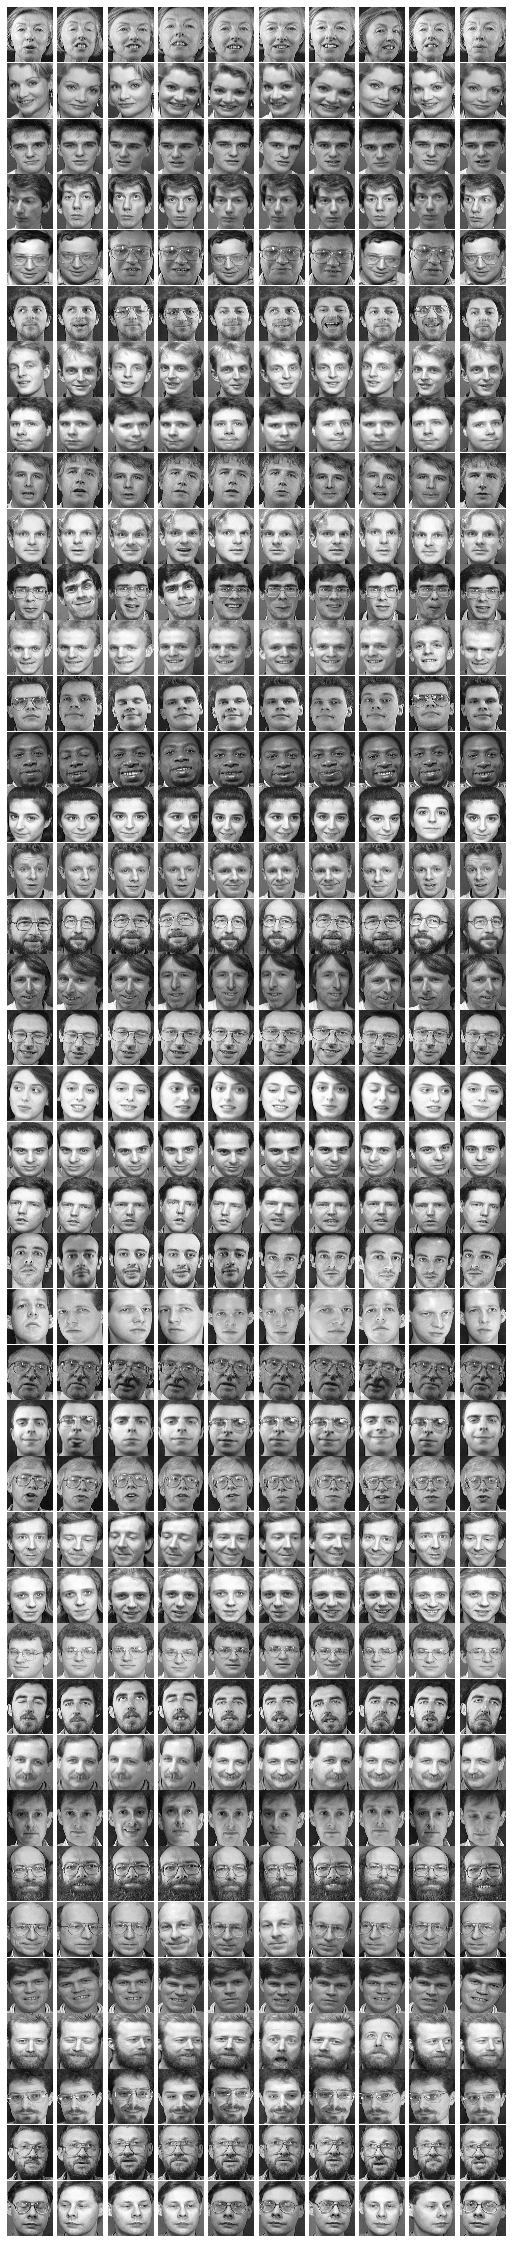

In [38]:
plot_faces(faces)

### PCA

In [55]:
from sklearn.decomposition import PCA

dimensions = 10
faces_pca = PCA(n_components=dimensions)
faces_pca.fit(faces)
print(faces_pca.components_.shape)

eigenfaces = faces_pca.components_.reshape((dimensions, 112, 92))
print(eigenfaces.shape)

(10, 10304)
(10, 112, 92)


### First Eigenface

The first component, known as the first eigenvector, is the set of most frequent characteristics of a face from this dataset. Every face starts with this eigenface, then adds components of the other eigenfaces to produce each unique face.

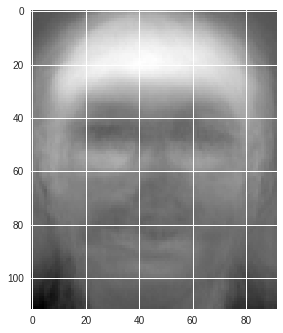

In [56]:
import matplotlib.pyplot as plt
plt.imshow(eigenfaces[0], cmap='gray');

### First 10 Eigenfaces

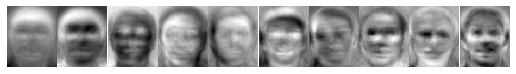

In [57]:
plot_eigenfaces(eigenfaces)

### Reduce the dimensionality of the original faces

In [58]:
faces_reduced = faces_pca.transform(faces)
print(faces_reduced.shape)

(400, 10)


### Try to recover the faces back from the reduced data

In [59]:
faces_recovered = pd.DataFrame(faces_pca.inverse_transform(faces_reduced))
print(faces_recovered.shape)
print(faces.shape)

(400, 10304)
(400, 10304)


we have recovered back faces, but with some data lost in the process

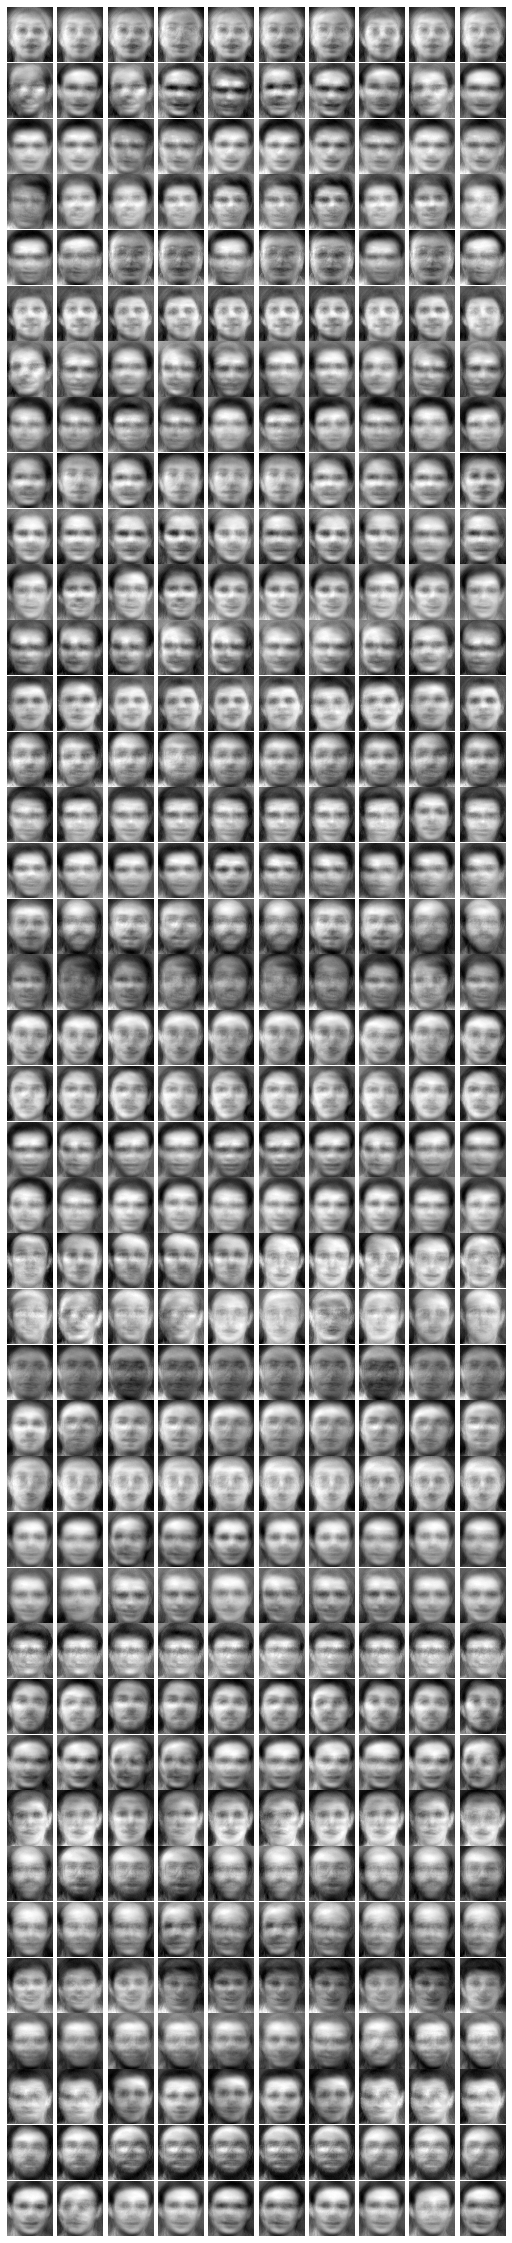

In [60]:
plot_faces(faces_recovered)

One can notice the huge amount of data loss - as we chose to reduce 10000+ dimensions to 10

## Ask PCA to preserve the quality - and determine the dimensions required as a result

In [61]:
from sklearn.decomposition import PCA

faces_pca = PCA(n_components=0.98) # 98% quality preserved
faces_pca.fit(faces)
print(faces_pca.components_.shape)

eigenfaces = faces_pca.components_.reshape((faces_pca.n_components_, 112, 92))
print(eigenfaces.shape)

(279, 10304)
(279, 112, 92)


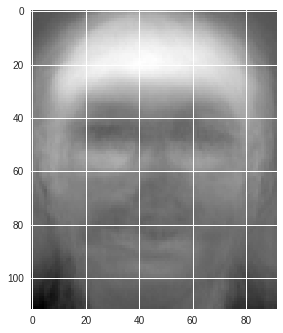

In [62]:
import matplotlib.pyplot as plt
plt.imshow(eigenfaces[0], cmap='gray');

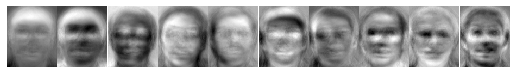

In [64]:
plot_eigenfaces(eigenfaces, 1)

In [65]:
faces_reduced = faces_pca.transform(faces)
print(faces_reduced.shape)

(400, 279)


In [66]:
faces_recovered = pd.DataFrame(faces_pca.inverse_transform(faces_reduced))
print(faces_recovered.shape)
print(faces.shape)

(400, 10304)
(400, 10304)


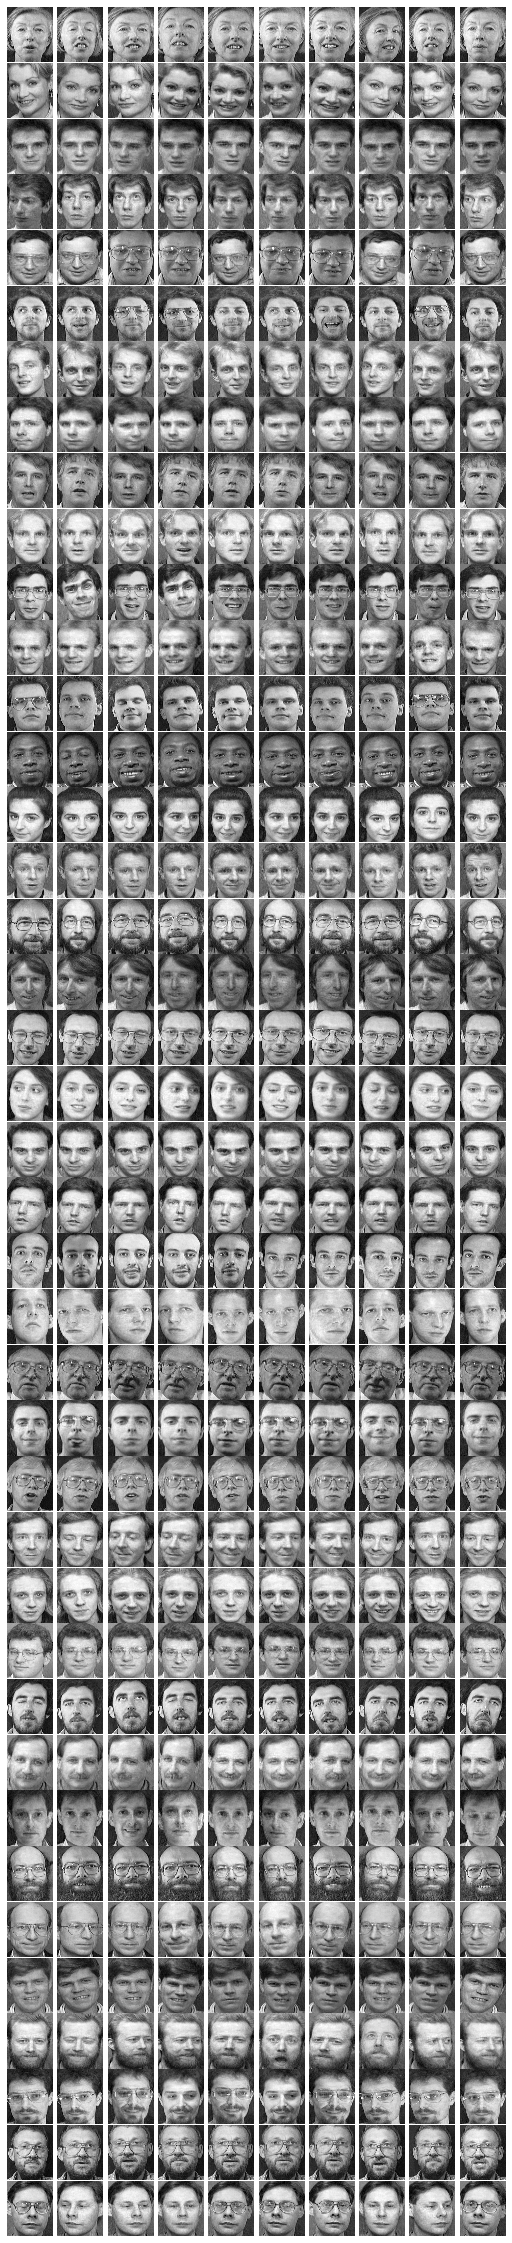

In [67]:
plot_faces(faces_recovered)

**Observation:** much closer to the original